# Notebook 03b — Chia tập và đo trần

Notebook này **không cải tiến gì**. Nó chuẩn bị hai thứ cho toàn bộ phần còn lại
của đồ án:

| Mục | Nội dung | Vì sao cần |
| --- | --- | --- |
| 1 | Chia `train` thành hai phần | Lưới an toàn chống khớp nhiễu khi chạy nhiều thí nghiệm |
| 2–5 | Bốn phép đo trần | Biết hướng nào còn dư địa, thay vì đoán |
| 6 | Xếp thứ tự ưu tiên | Kết luận: nên đầu tư vào đâu |

Cấu hình dùng xuyên suốt là cấu hình đã chốt ở Notebook 03:
`nohtml_stop` + `title_weighted`.

## 0. Chuẩn bị

In [1]:
import sys
import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
import reteco as R

DATA = Path(r"D:\RETECO-project\reteco_data\track1_tempo")
CACHE = Path("results")
CACHE.mkdir(exist_ok=True)

assert DATA.is_dir(), f"Dataset not found at {DATA}"
domains = R.list_domains(DATA)

# The configuration chosen in notebook 03
TOKENIZER = R.make_tokenizer(drop_html=True, stopwords=R.EXTENDED_STOPWORDS)
import re
HTML_TAG = re.compile(r"<[^>]+>")
HTML_ENTITY = re.compile(r"&(?:quot|amp|lt|gt|nbsp|apos|#\d+);")


def strip_markup(text):
    text = HTML_ENTITY.sub(" ", HTML_TAG.sub(" ", text))
    return re.sub(r"\s+", " ", text).strip()


def title_of(text):
    match = re.search(r"<p>", text)
    return text[:match.start()] if match else text


def query_form(text):
    """title_weighted: the title three times, then the whole post."""
    return strip_markup((title_of(text) + " ") * 3 + text)


print(f"{len(domains)} domains, configuration: nohtml_stop + title_weighted")

13 domains, configuration: nohtml_stop + title_weighted


In [2]:
# --- Shared chart style -------------------------------------------------
# One palette and one set of helpers for every figure, so the notebook reads
# as a single document rather than a pile of unrelated plots.
# Palette is colour-vision-deficiency safe; values are always labelled so the
# chart never relies on colour alone.
BLUE, ORANGE, TEAL, AMBER, PINK, VIOLET = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7")
SURFACE, INK, INK_SOFT, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS,
    "axes.labelcolor": INK_SOFT,
    "axes.labelsize": 9.5,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "font.size": 10,
    "figure.dpi": 120,
    "axes.linewidth": 0.9,
})


def finish(ax, title, subtitle=None, xlabel=None, ylabel=None,
           grid_axis="y", note=None):
    """Apply the shared layout: title block, recessive grid, minimal frame.

    The title carries the claim; the subtitle carries the qualifier. Keeping
    them apart stops titles from turning into sentences.
    """
    if subtitle:
        # Subtitle sits just above the axes; the title is offset further up in
        # POINTS, not axes fractions, so the gap holds at any figure size.
        ax.set_title(subtitle, loc="left", pad=8, fontsize=9.5, color=INK_MUTED)
        ax.annotate(title, xy=(0, 1), xycoords="axes fraction",
                    xytext=(0, 24), textcoords="offset points",
                    ha="left", va="bottom", fontsize=12.5,
                    fontweight="bold", color=INK, annotation_clip=False)
    else:
        ax.set_title(title, loc="left", pad=12, fontsize=12.5,
                     fontweight="bold", color=INK)

    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")

    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    # The gridline already marks the scale; the spine it runs into is noise.
    ax.spines["left" if grid_axis == "x" else "bottom"].set_color(AXIS)
    if grid_axis == "x":
        ax.spines["bottom"].set_visible(False)
    else:
        ax.spines["left"].set_visible(False)

    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    ax.tick_params(length=0)

    if note:
        ax.text(0, -0.34, note, transform=ax.transAxes, ha="left", va="top",
                fontsize=8.5, color=INK_MUTED)
    return ax


def label_bars(ax, bars, values, fmt="{:,.0f}", horizontal=True, pad=0.015):
    """Direct value labels. Always present, so colour never carries the number."""
    span = max(values) if values else 1
    for bar, value in zip(bars, values):
        if horizontal:
            ax.text(bar.get_width() + span * pad,
                    bar.get_y() + bar.get_height() / 2,
                    fmt.format(value), va="center", ha="left",
                    fontsize=8.5, color=INK_SOFT)
        else:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + span * pad,
                    fmt.format(value), ha="center", va="bottom",
                    fontsize=8.5, color=INK_SOFT)


def legend_below(ax, ncol=2, y=-0.30):
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, y),
              ncol=ncol, fontsize=9.5, handlelength=1.1, handleheight=1.1,
              columnspacing=1.8)

## 1. Chia `train` làm hai

### Vấn đề

Sắp tới sẽ chạy hàng chục thí nghiệm, mỗi lần giữ lại cấu hình điểm cao nhất.

Nhưng thử đủ nhiều thì **sẽ có cấu hình điểm cao chỉ vì may mắn** trên đúng tập
dữ liệu này, chứ không thực sự tốt hơn. Gọi là **khớp nhiễu**.

Cách phát hiện: thử cấu hình đó trên dữ liệu **chưa từng dùng để chọn**. Nếu nó
vẫn tốt thì là thật; nếu rớt thì là may mắn.

Mà `dev` chỉ được chạy **một lần duy nhất** ở cuối, nên không dùng làm chỗ kiểm
tra dọc đường được.

### Cách giải quyết

Cắt `train` làm hai phần:

| Phần | Tỉ lệ | Dùng để |
| --- | --- | --- |
| `fit` | 80% | Chạy thí nghiệm, chọn cấu hình |
| `check` | 20% | Kiểm tra lại — **tuyệt đối không dùng để chọn** |

Nếu một cấu hình thắng trên `fit` nhưng rớt trên `check` → khớp nhiễu → bỏ.

### Hai điều bắt buộc

**Cắt theo từng nhóm.** Nếu cắt ngẫu nhiên toàn bộ, có nhóm sẽ không còn câu hỏi
nào ở phần `check`.

**Cố định hạt giống ngẫu nhiên.** Mọi notebook phải dùng **đúng một cách chia**.
Mỗi notebook chia một kiểu thì các phép so sánh không còn ghép cặp được, và mọi
kiểm định thống kê mất hiệu lực.

In [3]:
split_file = CACHE / "split.json"

if split_file.exists():
    split = json.loads(split_file.read_text(encoding="utf-8"))
    print("Loaded existing split. This file must NOT be regenerated once")
    print("experiments have been run against it.")
else:
    queries_by_domain = {
        d: [qid for qid, _ in R.load_queries(DATA / d / "examples_train.jsonl")]
        for d in domains
    }
    split = R.make_split(queries_by_domain, fit_fraction=0.8, seed=0)
    split_file.write_text(json.dumps(split, indent=1), encoding="utf-8")
    print("Split created and saved.")

print(f"\n{'domain':<12}{'fit':>6}{'check':>7}{'total':>7}")
print("-" * 32)
total_fit = total_check = 0
for d in domains:
    f, c = len(split[d]["fit"]), len(split[d]["check"])
    total_fit += f
    total_check += c
    print(f"{d:<12}{f:>6}{c:>7}{f + c:>7}")
print("-" * 32)
print(f"{'TOTAL':<12}{total_fit:>6}{total_check:>7}{total_fit + total_check:>7}")

Split created and saved.

domain         fit  check  total
--------------------------------
bitcoin         56     14     70
cardano         29      7     36
economics       46     12     58
genealogy       64     16     80
history        449    112    561
hsm             84     21    105
iota             6      1      7
law             19      5     24
monero          37      9     46
politics        84     21    105
quant           19      5     24
travel          56     14     70
workplace       20      5     25
--------------------------------
TOTAL          969    242   1211


> **Cảnh báo về các nhóm nhỏ**
>
> Nhóm nhỏ nhất chỉ có 7 câu hỏi, nên phần `check` của nó chỉ còn 1–2 câu.
> Kết quả trên một nhóm như vậy gần như vô nghĩa.
>
> `check` chỉ nên đọc ở mức **macro trên cả 13 nhóm**, không đọc từng nhóm lẻ.

## 2. Chạy cấu hình hiện tại, lấy sâu 1000

Bốn phép đo phía dưới đều cần cùng một thứ: danh sách kết quả của cấu hình hiện
tại. Lấy sâu **1000** thay vì 100 để đo được đường cong recall ở mục 4.

Mất khoảng 15–20 phút.

In [4]:
run_file = CACHE / "diagnostics_runs.json"

if run_file.exists():
    saved = json.loads(run_file.read_text(encoding="utf-8"))
    runs, gold_all = saved["runs"], {d: {q: set(v) for q, v in g.items()}
                                     for d, g in saved["gold"].items()}
    print("Loaded from cache. Delete results/diagnostics_runs.json to rerun.")
else:
    runs, gold_all = {}, {}
    started = time.time()
    for i, domain in enumerate(domains, start=1):
        t0 = time.time()
        doc_ids, doc_texts = R.load_corpus(DATA / domain / "documents.jsonl")
        queries = R.load_queries(DATA / domain / "examples_train.jsonl")
        gold_all[domain] = R.load_qrels(DATA / domain / "qrels_train.txt")

        index = R.BM25(doc_ids, doc_texts, tokenizer=TOKENIZER)
        runs[domain] = {qid: [d for d, _ in index.search(query_form(text), top_k=1000)]
                        for qid, text in queries}
        del index, doc_ids, doc_texts

        print(f"  [{i:>2}/{len(domains)}] {domain:<12}{time.time() - t0:>6.0f}s",
              flush=True)

    run_file.write_text(json.dumps(
        {"runs": runs,
         "gold": {d: {q: sorted(v) for q, v in g.items()}
                  for d, g in gold_all.items()}}), encoding="utf-8")
    print(f"\nTotal: {(time.time() - started) / 60:.1f} min")

# Sanity: the top-100 slice must reproduce notebook 03's number
check = {d: R.evaluate({q: ids[:100] for q, ids in runs[d].items()}, gold_all[d])
         for d in domains}
print(f"\nmacro nDCG@10 at top-100 = {R.macro(check):.4f}"
      f"   (notebook 03 reported 0.1463)")

  [ 1/13] bitcoin         58s
  [ 2/13] cardano         29s
  [ 3/13] economics       21s
  [ 4/13] genealogy       44s
  [ 5/13] history        127s
  [ 6/13] hsm             55s
  [ 7/13] iota             5s
  [ 8/13] law             11s
  [ 9/13] monero          26s
  [10/13] politics        42s
  [11/13] quant            6s
  [12/13] travel          32s
  [13/13] workplace       11s

Total: 7.8 min

macro nDCG@10 at top-100 = 0.1463   (notebook 03 reported 0.1463)


## 3. Trần của việc xếp hạng lại

### Xếp hạng lại là gì

Hệ thống hiện tại trả về 100 tài liệu đã xếp hạng. Bước xếp hạng lại nhận 100
tài liệu đó rồi **sắp xếp lại chúng** cho tốt hơn.

Điểm cốt lõi: nó **không thêm được tài liệu mới**. Tài liệu nào bước tìm kiếm
bỏ sót thì mất luôn.

### Vậy tối đa nó làm được gì

Giả sử có một bộ xếp hạng lại **hoàn hảo**. Nó sẽ đưa **mọi tài liệu đúng đang
nằm trong 100 kết quả** lên những vị trí đầu.

Đó là mức trần. Không bộ xếp hạng nào vượt qua được, vì vượt qua nghĩa là tìm
ra tài liệu mà bước trước không hề lấy.

Con số này **tính được chính xác**, không phải đoán: đếm xem mỗi câu hỏi có bao
nhiêu tài liệu đúng trong 100 kết quả, rồi tính nDCG@10 khi xếp hết chúng lên đầu.

### Vì sao cần biết

Nó trả lời câu hỏi **có đáng đầu tư vào bước xếp hạng lại không**.

- Trần cao hơn điểm hiện tại nhiều → đáng làm
- Trần sát điểm hiện tại → bước tìm kiếm mới là chỗ nghẽn, xếp lại không cứu được

In [5]:
CANDIDATE_DEPTHS = [10, 50, 100, 200, 500, 1000]

ceiling_by_depth = {}
for depth in CANDIDATE_DEPTHS:
    per_domain = {}
    for d in domains:
        values = [R.rerank_ceiling(runs[d][q][:depth], gold_all[d][q])
                  for q in gold_all[d] if q in runs[d]]
        per_domain[d] = float(np.mean(values)) if values else 0.0
    ceiling_by_depth[depth] = float(np.mean(list(per_domain.values())))

current = R.macro(check)
print(f"{'depth':>8}{'rerank ceiling':>18}{'times current':>16}")
print("-" * 42)
for depth, value in ceiling_by_depth.items():
    print(f"{depth:>8}{value:>18.4f}{value / current:>15.1f}x")
print(f"\ncurrent score (no reranking): {current:.4f}")

   depth    rerank ceiling   times current
------------------------------------------
      10            0.2262            1.5x
      50            0.3915            2.7x
     100            0.4584            3.1x
     200            0.5400            3.7x
     500            0.6386            4.4x
    1000            0.7296            5.0x

current score (no reranking): 0.1463


## 4. Lấy sâu hơn có tìm thêm được đáp án không

### Recall là gì

**Recall@k** = tỉ lệ tài liệu đúng nằm trong `k` kết quả đầu.

Ví dụ: câu hỏi có 5 đáp án, lấy 100 kết quả thì bắt được 2 → recall@100 = 2/5 = 0,4.

### Đây là câu hỏi KHÁC với mục 3

Hai mục đo hai thứ khác nhau, **đơn vị khác nhau**, không so trực tiếp được:

| Mục | Câu hỏi | Đơn vị |
| --- | --- | --- |
| 3 | Sắp xếp lại 100 kết quả hiện có, được thêm bao nhiêu điểm? | nDCG@10 |
| 4 | Lấy 500 hay 1000 thay vì 100, có bắt thêm được đáp án không? | recall |

Vì vậy biểu đồ dưới chia **hai khung riêng**, mỗi khung một đơn vị. Đặt chung
một trục sẽ khiến người đọc so hai cột cao thấp mà chúng vốn không so được.

### Vì sao cần biết

Nếu recall vẫn tăng mạnh khi lấy sâu hơn, có một hướng đáng thử: **lấy 500–1000
kết quả rồi mới xếp hạng lại**, thay vì chỉ xếp lại 100.

Đổi lại, bước xếp hạng lại sẽ tốn gấp 5–10 lần.

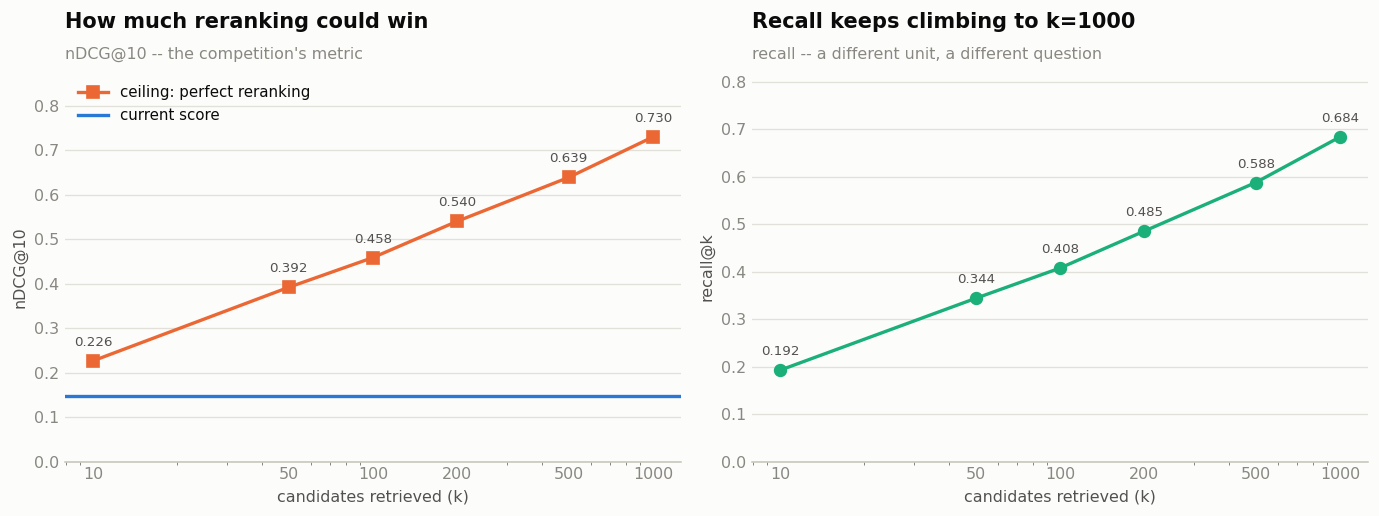

   depth   ceiling (nDCG@10)    recall@k   recall gain
------------------------------------------------------
      10              0.2262      0.1923       +0.1923
      50              0.3915      0.3438       +0.1515
     100              0.4584      0.4075       +0.0638
     200              0.5400      0.4854       +0.0779
     500              0.6386      0.5877       +0.1023
    1000              0.7296      0.6839       +0.0961


In [6]:
recall_by_depth = {}
for depth in CANDIDATE_DEPTHS:
    per_domain = {}
    for d in domains:
        values = [R.recall_at_k(runs[d][q], gold_all[d][q], depth)
                  for q in gold_all[d] if q in runs[d]]
        values = [v for v in values if v is not None]
        per_domain[d] = float(np.mean(values)) if values else 0.0
    recall_by_depth[depth] = float(np.mean(list(per_domain.values())))


# Two panels, not one. The two curves are measured in different units --
# one is nDCG@10, the other is recall -- and putting them on a shared axis
# invites the reader to compare heights that are not comparable.
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4))
depths = list(CANDIDATE_DEPTHS)

# LEFT: everything in nDCG@10, the competition's unit
axes[0].plot(depths, [ceiling_by_depth[k] for k in depths],
             color=ORANGE, linewidth=2, marker="s", markersize=7,
             label="ceiling: perfect reranking")
axes[0].axhline(current, color=BLUE, linewidth=2, label="current score")
for k in depths:
    axes[0].annotate(f"{ceiling_by_depth[k]:.3f}", (k, ceiling_by_depth[k]),
                     textcoords="offset points", xytext=(0, 9),
                     ha="center", fontsize=8, color=INK_SOFT)
axes[0].set_xscale("log")
axes[0].set_xticks(depths)
axes[0].set_xticklabels([str(k) for k in depths])
axes[0].set_ylim(0, max(ceiling_by_depth.values()) * 1.2)
finish(axes[0], "How much reranking could win",
       subtitle="nDCG@10 -- the competition's metric",
       xlabel="candidates retrieved (k)", ylabel="nDCG@10")
axes[0].legend(frameon=False, loc="upper left", fontsize=9)

# RIGHT: recall, a different unit and a different question
axes[1].plot(depths, [recall_by_depth[k] for k in depths],
             color=TEAL, linewidth=2, marker="o", markersize=7)
for k in depths:
    axes[1].annotate(f"{recall_by_depth[k]:.3f}", (k, recall_by_depth[k]),
                     textcoords="offset points", xytext=(0, 9),
                     ha="center", fontsize=8, color=INK_SOFT)
axes[1].set_xscale("log")
axes[1].set_xticks(depths)
axes[1].set_xticklabels([str(k) for k in depths])
axes[1].set_ylim(0, max(recall_by_depth.values()) * 1.2)

early_gain = recall_by_depth[depths[1]] - recall_by_depth[depths[0]]
late_gain = recall_by_depth[depths[-1]] - recall_by_depth[depths[-2]]
headline = ("Recall keeps climbing to k=1000"
            if late_gain > early_gain * 0.5
            else "Recall flattens as depth grows")
finish(axes[1], headline,
       subtitle="recall -- a different unit, a different question",
       xlabel="candidates retrieved (k)", ylabel="recall@k")

plt.tight_layout()
plt.show()

print(f"{'depth':>8}{'ceiling (nDCG@10)':>20}{'recall@k':>12}"
      f"{'recall gain':>14}")
print("-" * 54)
previous = 0.0
for k in depths:
    print(f"{k:>8}{ceiling_by_depth[k]:>20.4f}{recall_by_depth[k]:>12.4f}"
          f"{recall_by_depth[k] - previous:>+14.4f}")
    previous = recall_by_depth[k]

## 5. Có bao nhiêu đáp án BM25 không bao giờ với tới

Đây là phép đo quan trọng nhất notebook này, vì nó quyết định **hướng đi lớn**
của phần còn lại.

### Vấn đề

BM25 chấm điểm bằng cách **đếm từ chung** giữa câu hỏi và tài liệu. Không có từ
chung thì điểm bằng 0.

Nên nếu một tài liệu đúng **không dùng chung một từ nào** với câu hỏi, BM25
**không bao giờ** lấy được nó. Chỉnh `k1`, đổi tokenizer, lấy sâu 10.000 — vô ích.

Ví dụ: câu hỏi viết *"xe điện"*, tài liệu viết *"ô tô chạy pin"*. Cùng ý nghĩa,
không chung từ nào. BM25 bó tay.

### Phép đo

Với mỗi cặp (câu hỏi, tài liệu đúng): hai bên có chung **ít nhất một từ** không?

### Kết quả nói lên điều gì

| Nếu tỉ lệ với tới | Nghĩa là | Nên làm |
| --- | --- | --- |
| Thấp (dưới ~80%) | BM25 bị chặn về mặt cấu trúc | **Bắt buộc** cần mô hình hiểu nghĩa |
| Cao (trên ~95%) | BM25 tìm được, chỉ xếp hạng kém | Ưu tiên **xếp hạng lại**, rẻ hơn nhiều |

Đây là hai bài toán khác nhau, cách chữa cũng khác nhau. Phép đo này cho biết
bài toán đang gặp là bài toán nào.

In [7]:
reach_file = CACHE / "lexical_reach.json"

if reach_file.exists():
    reachable = json.loads(reach_file.read_text(encoding="utf-8"))
    print("Loaded from cache.")
else:
    reachable = {}
    for i, domain in enumerate(domains, start=1):
        doc_ids, doc_texts = R.load_corpus(DATA / domain / "documents.jsonl")
        text_of = dict(zip(doc_ids, doc_texts))
        queries = dict(R.load_queries(DATA / domain / "examples_train.jsonl"))

        hit = total = 0
        for qid, gold_ids in gold_all[domain].items():
            if qid not in queries:
                continue
            query_terms = set(TOKENIZER(query_form(queries[qid])))
            for doc_id in gold_ids:
                total += 1
                if query_terms & set(TOKENIZER(text_of.get(doc_id, ""))):
                    hit += 1

        reachable[domain] = {"reachable": hit, "total": total}
        print(f"  [{i:>2}/{len(domains)}] {domain:<12}"
              f"{100 * hit / max(total, 1):>7.1f}% reachable", flush=True)
        del doc_ids, doc_texts, text_of

    reach_file.write_text(json.dumps(reachable, indent=1), encoding="utf-8")

rates = [100 * v["reachable"] / max(v["total"], 1) for v in reachable.values()]
all_hit = sum(v["reachable"] for v in reachable.values())
all_total = sum(v["total"] for v in reachable.values())
print(f"\nOverall: {all_hit:,} of {all_total:,} gold documents share at least")
print(f"one term with their query ({100 * all_hit / all_total:.1f}%).")
print(f"The remaining {100 - 100 * all_hit / all_total:.1f}% are unreachable by")
print("any lexical method, however it is tuned.")

  [ 1/13] bitcoin        99.6% reachable
  [ 2/13] cardano       100.0% reachable
  [ 3/13] economics     100.0% reachable
  [ 4/13] genealogy      99.1% reachable
  [ 5/13] history        99.3% reachable
  [ 6/13] hsm            99.6% reachable
  [ 7/13] iota           93.1% reachable
  [ 8/13] law           100.0% reachable
  [ 9/13] monero         99.2% reachable
  [10/13] politics       99.3% reachable
  [11/13] quant          98.4% reachable
  [12/13] travel         98.9% reachable
  [13/13] workplace     100.0% reachable

Overall: 4,351 of 4,381 gold documents share at least
one term with their query (99.3%).
The remaining 0.7% are unreachable by
any lexical method, however it is tuned.


## 6. Khoảng cách theo từng nhóm

Điểm cuối là trung bình của 13 nhóm với trọng số bằng nhau, nên nhóm điểm thấp
là nơi còn nhiều dư địa nhất.

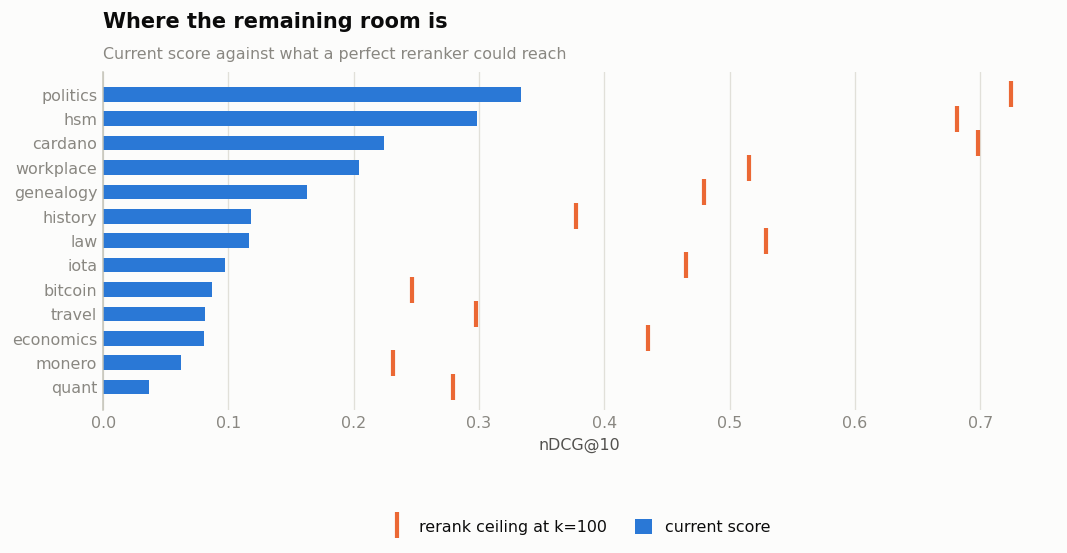

domain        current  ceiling     room  reachable  topics
------------------------------------------------------------
quant          0.0367   0.2795   0.2428      98.4%      24
monero         0.0622   0.2316   0.1694      99.2%      46
economics      0.0804   0.4345   0.3541     100.0%      58
travel         0.0813   0.2978   0.2165      98.9%      70
bitcoin        0.0872   0.2468   0.1596      99.6%      70
iota           0.0975   0.4653   0.3678      93.1%       7
law            0.1164   0.5286   0.4122     100.0%      24
history        0.1176   0.3771   0.2594      99.3%     561
genealogy      0.1625   0.4793   0.3168      99.1%      80
workplace      0.2040   0.5150   0.3111     100.0%      25
cardano        0.2245   0.6985   0.4740     100.0%      36
hsm            0.2980   0.6812   0.3832      99.6%     105
politics       0.3333   0.7242   0.3908      99.3%     105


In [8]:
OFFICIAL = {
    "bitcoin": 0.0695, "cardano": 0.1349, "economics": 0.0382,
    "genealogy": 0.1003, "history": 0.0691, "hsm": 0.1627,
    "iota": 0.0199, "law": 0.0943, "monero": 0.0278,
    "politics": 0.2792, "quant": 0.0255, "travel": 0.0429,
    "workplace": 0.0777,
}

order = sorted(domains, key=lambda d: check[d]["ndcg"])
fig, ax = plt.subplots(figsize=(9.0, 5.0))
y = np.arange(len(order))

ceiling_per_domain = {
    d: float(np.mean([R.rerank_ceiling(runs[d][q][:100], gold_all[d][q])
                      for q in gold_all[d] if q in runs[d]]))
    for d in domains
}

ax.barh(y, [check[d]["ndcg"] for d in order], height=0.6,
        color=BLUE, label="current score")
ax.plot([ceiling_per_domain[d] for d in order], y, linestyle="none",
        marker="|", markersize=16, markeredgewidth=2.5,
        color=ORANGE, label="rerank ceiling at k=100")

ax.set_yticks(y)
ax.set_yticklabels(order)
finish(ax, "Where the remaining room is",
       subtitle="Current score against what a perfect reranker could reach",
       xlabel="nDCG@10", grid_axis="x")
legend_below(ax, ncol=2, y=-0.28)
plt.tight_layout()
plt.show()

print(f"{'domain':<12}{'current':>9}{'ceiling':>9}{'room':>9}"
      f"{'reachable':>11}{'topics':>8}")
print("-" * 60)
for d in order:
    ceiling = ceiling_per_domain[d]
    reach = 100 * reachable[d]["reachable"] / max(reachable[d]["total"], 1)
    print(f"{d:<12}{check[d]['ndcg']:>9.4f}{ceiling:>9.4f}"
          f"{ceiling - check[d]['ndcg']:>9.4f}{reach:>10.1f}%"
          f"{check[d]['n_topics']:>8}")

## 7. Kết luận: nên đầu tư vào đâu

In [9]:
summary = {
    "current_ndcg": current,
    "rerank_ceiling_at_100": ceiling_by_depth[100],
    "rerank_ceiling_at_1000": ceiling_by_depth[1000],
    "recall_at_100": recall_by_depth[100],
    "recall_at_1000": recall_by_depth[1000],
    "lexically_reachable_pct": 100 * all_hit / all_total,
    "split_fit": total_fit,
    "split_check": total_check,
}
(CACHE / "diagnostics_summary.json").write_text(
    json.dumps(summary, indent=1), encoding="utf-8")

headroom_rerank = ceiling_by_depth[100] - current
headroom_depth = recall_by_depth[1000] - recall_by_depth[100]
unreachable = 100 - 100 * all_hit / all_total

print("Headroom of each direction, measured rather than guessed:\n")
print(f"  reranking the existing top-100   {headroom_rerank:>+8.4f}"
      f"   ({ceiling_by_depth[100] / current:.1f}x current)")
print(f"  retrieving deeper (100 -> 1000)  {headroom_depth:>+8.4f} recall")
print(f"  gold unreachable by any lexical  {unreachable:>8.1f}% of gold documents")
print()
print("  The last line is the part no amount of BM25 tuning can fix: those")
print("  documents share no term with their query, so only a method that")
print("  matches on meaning rather than on words can retrieve them.")

Headroom of each direction, measured rather than guessed:

  reranking the existing top-100    +0.3121   (3.1x current)
  retrieving deeper (100 -> 1000)   +0.2763 recall
  gold unreachable by any lexical       0.7% of gold documents

  The last line is the part no amount of BM25 tuning can fix: those
  documents share no term with their query, so only a method that
  matches on meaning rather than on words can retrieve them.


## Tổng kết

| Việc | Kết quả |
| --- | --- |
| Chia tập | Lưu ở `results/split.json` — **không tạo lại** sau khi đã chạy thí nghiệm |
| Trần xếp hạng lại | Xem mục 3 |
| Đường cong recall | Xem mục 4 |
| Trần từ vựng | Xem mục 5 — phần BM25 không bao giờ chạm tới được |
| Nhóm còn dư địa | Xem mục 6 |

**Cách dùng tập `check` từ giờ:** chạy thí nghiệm trên toàn bộ `train`, rồi dùng
`R.restrict(results, split, "fit")` và `R.restrict(results, split, "check")` để
đọc ra hai con số từ **cùng một lần chạy**. Không chạy hai lần.

**Tiếp theo:** Notebook 04 — so ba mô hình truy xuất.